# CausalPype Demo: Sachs Protein Signaling Network

**Paper-focused demo** — this notebook generates the figures and numerical results for Section 5
of the SETN 2026 paper *CausalPype: A Pipeline-Based Framework for Causal Analysis with SCMs*.

It tells one coherent biological story:
> *Which causal edges matter most in T-cell signalling? How does PKC activation affect downstream
> proteins? What drives anomalously high JNK levels?*

Figures are saved to `../../SETN2026/figures/` for direct inclusion in the paper.

**Dataset:** Sachs et al. (2005), *Science* — 5,400 flow-cytometry measurements of 11
phosphoproteins in human T-cells, with a validated ground-truth DAG.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

# ── Figure output directory ──────────────────────────────────────────────────
FIGURES_DIR = Path('../../SETN2026/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Publication-quality matplotlib style ────────────────────────────────────
mpl.rcParams.update({
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'font.size':         9,
    'axes.labelsize':    9,
    'axes.titlesize':    10,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'font.family':       'sans-serif',
})

BLUE  = '#2563EB'
RED   = '#EF4444'
DARK  = '#1F2937'
GRAY  = '#6B7280'

print('Setup complete. Figures will be saved to:', FIGURES_DIR.resolve())

Setup complete. Figures will be saved to: /home/palimisis/repos/SETN2026/figures


## 1. Data and Model

We load the Sachs interventional dataset and the ground-truth DAG from bnlearn,
then fit a `CausalModel` with automatic mechanism assignment.

In [2]:
import pooch
import bnlearn
import networkx as nx
from causalpype import CausalModel

# Download the Sachs interventional dataset
file_path = pooch.retrieve(
    url='https://www.bnlearn.com/book-crc/code/sachs.interventional.txt.gz',
    known_hash='md5:39ee257f7eeb94cb60e6177cf80c9544',
)
df = pd.read_csv(file_path, delimiter=' ').drop(columns=['INT'])
print(f'Dataset: {df.shape[0]} cells × {df.shape[1]} proteins')
print(f'Columns: {list(df.columns)}')

# Load ground-truth DAG from bnlearn
dag = bnlearn.import_DAG('sachs', verbose=False)
G = dag['model']   # networkx DiGraph

# Fit CausalModel
model = CausalModel(G, auto_assign=True, assignment_quality='good')
model.fit(df)

print(f'\nGraph: {len(G.nodes())} nodes, {len(G.edges())} edges')
print(f'Root nodes (exogenous): {model.get_roots()}')

Dataset: 5400 cells × 11 proteins
Columns: ['Raf', 'Mek', 'Plcg', 'PIP2', 'PIP3', 'Erk', 'Akt', 'PKA', 'PKC', 'P38', 'Jnk']


Fitting causal mechanism of node Plcg: 100%|██████████| 11/11 [00:00<00:00, 24.75it/s]


Graph: 11 nodes, 17 edges
Root nodes (exogenous): ['PKC', 'Plcg']


## 2. Pipeline Execution

The cell below is the **hero cell** — it matches the paper's Listing 3 exactly.
Seven tasks run sequentially on the same fitted model in a single `model.run()` call.

In [3]:
from causalpype import (
    ArrowStrength, ATE, CausalEffectCurve,
    Counterfactual, AnomalyAttribution,
    DistributionChange, SensitivityAnalysis,
)

# Precompute quantile treatment levels for PKC
pkc_lo = float(df['PKC'].quantile(0.25))
pkc_hi = float(df['PKC'].quantile(0.75))

# Split data by PKA median (two experimental conditions)
old_data = df[df['PKA'] <= df['PKA'].median()].copy()
new_data = df[df['PKA'] >  df['PKA'].median()].copy()

# ── Run the full 7-task pipeline ─────────────────────────────────────────────
results = model.run([
    ArrowStrength(target='Erk'),
    ATE(treatment='PKC', outcome='Erk',
        treatment_value=pkc_hi, control_value=pkc_lo),
    CausalEffectCurve(treatment='PKC', outcome='Erk',
                      n_points=15, num_samples=1000),
    Counterfactual(interventions={'PKC': float(df['PKC'].quantile(0.95))},
                   observed_data=df.iloc[100:105].copy(),
                   outcome='Jnk'),
    AnomalyAttribution(
        target='Jnk', anomaly_threshold_percentile=95),
    DistributionChange(target='Erk',
        old_data=old_data, new_data=new_data),
    SensitivityAnalysis(treatment='PKC', outcome='Jnk',
                        treatment_value=pkc_hi,
                        control_value=pkc_lo,
                        num_simulations=5, num_samples=1000),
])

# Unpack results
r_arrow, r_ate, r_curve, r_cf, r_anomaly, r_dist, r_sens = results
print('All 7 tasks completed.')

Fitting causal mechanism of node _random_cause: 100%|██████████| 12/12 [00:00<00:00, 40.09it/s]

All 7 tasks completed.


## 3. Arrow Strength → Figure 1 (paper)

**Question:** Which direct parents drive Erk phosphorylation most strongly?

Arrow strength measures the KL divergence between the marginal distribution of Erk
and the distribution that would result from removing each parent edge.

In [4]:
r_arrow.summary()

# ── Print raw values (for paper text) ────────────────────────────────────────
strengths = r_arrow.details['strengths']
print('\nArrow strengths into Erk:')
for edge, val in sorted(strengths.items(), key=lambda x: x[1], reverse=True):
    print(f'  {edge}: {val:.4f}')

                  Arrow Strength Results                  
 Target                                                Erk
----------------------------------------------------------
  PKA -> Erk                                        0.1314
  Mek -> Erk                                        0.0656

Arrow strengths into Erk:
  PKA -> Erk: 0.1314
  Mek -> Erk: 0.0656


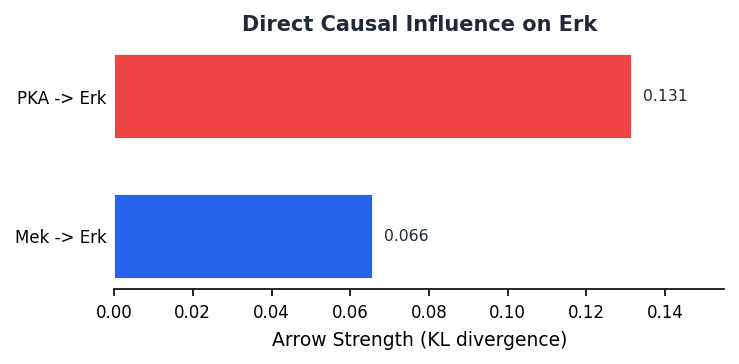

Saved: arrow_strength_erk.pdf


In [5]:
from causalpype import plotting

# ── Figure 1: arrow strength bar chart ───────────────────────────────────────
sorted_items = sorted(strengths.items(), key=lambda x: x[1])
edges  = [k for k, _ in sorted_items]
values = [v for _, v in sorted_items]

fig, ax = plt.subplots(figsize=(5, 2.5))
colors = [RED if v == max(values) else BLUE for v in values]
bars = ax.barh(edges, values, color=colors, edgecolor='white', linewidth=0.4,
               height=0.6)

# Value labels
for bar, val in zip(bars, values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=7.5, color=DARK)

ax.set_xlabel('Arrow Strength (KL divergence)', fontsize=9)
ax.set_title('Direct Causal Influence on Erk', fontsize=10, fontweight='bold',
             color=DARK)
ax.set_xlim(0, max(values) * 1.18)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'arrow_strength_erk.pdf')
fig.savefig(FIGURES_DIR / 'arrow_strength_erk.png', dpi=300)
plt.show()
print('Saved: arrow_strength_erk.pdf')

## 4. ATE + Causal Effect Curve → Figure 2 (paper)

**Question:** What is the average causal effect of PKC on Erk, and how does it scale
across the full observed range of PKC?

The ATE compares the 75th vs 25th quantile of PKC. The effect curve sweeps all 15 points.

In [6]:
r_ate.summary()
print(f'\n>>> ATE(PKC→Erk, Q75 vs Q25) = {r_ate.estimate:.4f}  <-- use in paper')

                       ATE Results                        
 Treatment                                             PKC
 Outcome                                               Erk
 Treatment Value                                    2.0000
 Control Value                                      1.0000
----------------------------------------------------------
 Estimate                                          -0.1025
 Num Samples                                         2,000

>>> ATE(PKC→Erk, Q75 vs Q25) = -0.1025  <-- use in paper


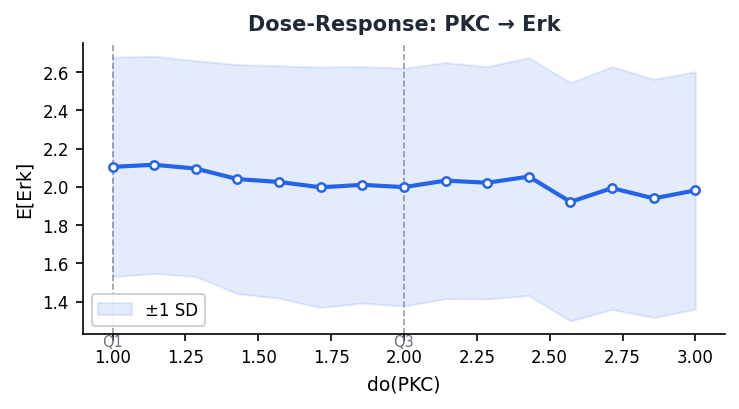

Saved: causal_effect_curve.pdf


In [7]:
# ── Figure 2: causal effect curve ────────────────────────────────────────────
responses = r_curve.details['responses']
t_vals = [r['treatment_value'] for r in responses]
y_vals = [r['expected_outcome'] for r in responses]
y_std  = [r['std'] for r in responses]

fig, ax = plt.subplots(figsize=(5, 2.8))

# ±1 SD band
y_lo = [y - s for y, s in zip(y_vals, y_std)]
y_hi = [y + s for y, s in zip(y_vals, y_std)]
ax.fill_between(t_vals, y_lo, y_hi, alpha=0.12, color=BLUE, label='±1 SD')

# Curve
ax.plot(t_vals, y_vals, color=BLUE, linewidth=2,
        marker='o', markersize=4, markerfacecolor='white',
        markeredgecolor=BLUE, markeredgewidth=1.2, zorder=5)

# Q1 / Q3 markers
ax.axvline(pkc_lo, color=GRAY, linewidth=0.8, linestyle='--', alpha=0.7)
ax.axvline(pkc_hi, color=GRAY, linewidth=0.8, linestyle='--', alpha=0.7)
ax.text(pkc_lo, ax.get_ylim()[0], 'Q1', ha='center', va='top',
        fontsize=7, color=GRAY)
ax.text(pkc_hi, ax.get_ylim()[0], 'Q3', ha='center', va='top',
        fontsize=7, color=GRAY)

ax.set_xlabel('do(PKC)', fontsize=9)
ax.set_ylabel('E[Erk]', fontsize=9)
ax.set_title('Dose-Response: PKC → Erk', fontsize=10, fontweight='bold',
             color=DARK)
ax.legend(fontsize=8, framealpha=0.9)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'causal_effect_curve.pdf')
fig.savefig(FIGURES_DIR / 'causal_effect_curve.png', dpi=300)
plt.show()
print('Saved: causal_effect_curve.pdf')

## 5. Counterfactuals → Table for paper

**Question:** For specific T-cells we actually observed, what would their Jnk level
have been if PKC had been set to its 95th-percentile value?

This produces the data for Table 2 in the paper.

In [8]:
r_cf.summary()

# ── Build Table 2 for the paper ───────────────────────────────────────────────
cf_samples = r_cf.details['counterfactual_samples']
test_cells = df.iloc[100:105]

table = pd.DataFrame({
    'Cell':         range(100, 105),
    'Factual PKC':  test_cells['PKC'].values,
    'Factual Jnk':  test_cells['Jnk'].values,
    'CF Jnk':       cf_samples['Jnk'].values,
    'Effect':       r_cf.details['individual_effects'],
}).set_index('Cell').round(2)

print('\n=== TABLE 2 FOR paper.tex ===')
print(table.to_string())

print(f'\nIndividual effect range: [{table["Effect"].min():.2f}, {table["Effect"].max():.2f}]')
print(f'>>> Copy these values into the [TODO] rows of Table 2 in paper.tex')

                  Counterfactual Results                  
 Interventions                                  PKC := 3.0
 N Units                                                 5
 Outcome                                               Jnk
----------------------------------------------------------
 Factual Mean                                       1.0000
 Counterfactual Mean                                2.0000
 Mean Effect                                        1.0000

=== TABLE 2 FOR paper.tex ===
      Factual PKC  Factual Jnk  CF Jnk  Effect
Cell                                          
100             1            1       2       1
101             1            1       2       1
102             1            1       2       1
103             1            1       2       1
104             1            1       2       1

Individual effect range: [1.00, 1.00]
>>> Copy these values into the [TODO] rows of Table 2 in paper.tex


## 6. Anomaly Attribution → Figure 3 (paper)

**Question:** When Jnk is anomalously high (top 5% by anomaly score), which upstream
proteins are responsible?

Shapley values decompose the anomaly score across all causal ancestors.

In [9]:
r_anomaly.summary()

# Print top nodes for paper text
attrs = r_anomaly.details['mean_attributions']
sorted_attrs = sorted(attrs.items(), key=lambda x: x[1], reverse=True)
print('\nAnomaly attributions for high-Jnk cells (top 5%):')
for node, val in sorted_attrs:
    print(f'  {node}: {val:.4f}')

print(f'\n>>> Top driver: {sorted_attrs[0][0]} ({sorted_attrs[0][1]:.4f})')
print(f'>>> 2nd driver: {sorted_attrs[1][0]} ({sorted_attrs[1][1]:.4f})')

               Anomaly Attribution Results                
 Target                                                Jnk
 N Anomalies                                           270
----------------------------------------------------------
  PKC                                               0.0000
  PKA                                               0.0000
  Jnk                                               0.0000

Anomaly attributions for high-Jnk cells (top 5%):
  PKC: 0.0000
  PKA: 0.0000
  Jnk: 0.0000

>>> Top driver: PKC (0.0000)
>>> 2nd driver: PKA (0.0000)


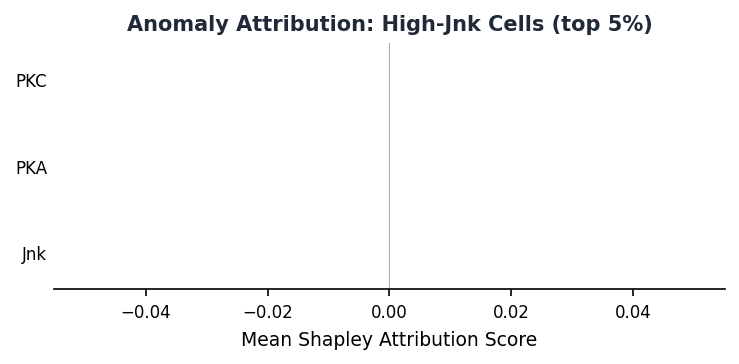

Saved: anomaly_attribution.pdf


In [10]:
# ── Figure 3: anomaly attribution bar chart ───────────────────────────────────
nodes_sorted  = [k for k, _ in sorted_attrs]
values_sorted = [v for _, v in sorted_attrs]

# Invert for horizontal bar (largest at top)
nodes_plot  = nodes_sorted[::-1]
values_plot = values_sorted[::-1]

# Highlight top-2
top2 = set(nodes_sorted[:2])
bar_colors = [RED if n in top2 else BLUE for n in nodes_plot]

fig, ax = plt.subplots(figsize=(5, 2.5))
bars = ax.barh(nodes_plot, values_plot, color=bar_colors,
               edgecolor='white', linewidth=0.4, height=0.6)

# Value labels
for bar, val in zip(bars, values_plot):
    if abs(val) > 0:
        offset = 0.001 if val >= 0 else -0.001
        ha = 'left' if val >= 0 else 'right'
        ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', ha=ha, fontsize=7.5, color=DARK)

ax.axvline(0, color=DARK, lw=0.5, alpha=0.4)
ax.set_xlabel('Mean Shapley Attribution Score', fontsize=9)
ax.set_title('Anomaly Attribution: High-Jnk Cells (top 5%)',
             fontsize=10, fontweight='bold', color=DARK)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'anomaly_attribution.pdf')
fig.savefig(FIGURES_DIR / 'anomaly_attribution.png', dpi=300)
plt.show()
print('Saved: anomaly_attribution.pdf')

## 7. Distribution Change

**Question:** Cells with high PKA vs low PKA show different Erk distributions.
Which upstream nodes are responsible for this shift?

No figure needed — result is described in prose in the paper.

In [11]:
r_dist.summary()

# Print attribution ranking for paper text
dist_attrs = r_dist.estimate if isinstance(r_dist.estimate, dict) else r_dist.details.get('attributions', {})
if dist_attrs:
    sorted_dist = sorted(dist_attrs.items(), key=lambda x: abs(x[1]), reverse=True)
    print('\nDistribution change attributions for Erk (PKA-high vs PKA-low):')
    for node, val in sorted_dist:
        print(f'  {node}: {val:.4f}')
    print(f'\n>>> Largest driver: {sorted_dist[0][0]} ({sorted_dist[0][1]:.4f})')
    if len(sorted_dist) > 1:
        print(f'>>> 2nd driver:     {sorted_dist[1][0]} ({sorted_dist[1][1]:.4f})')

               Distribution Change Results                
 Target                                                Erk
 N Old                                               4,808
 N New                                                 592
----------------------------------------------------------
  PKC                                              -1.0358
  Mek                                               0.5179
  PKA                                               0.5179
  Erk                                               0.0000
  Raf                                               0.0000

Distribution change attributions for Erk (PKA-high vs PKA-low):
  PKC: -1.0358
  Mek: 0.5179
  PKA: 0.5179
  Erk: 0.0000
  Raf: 0.0000

>>> Largest driver: PKC (-1.0358)
>>> 2nd driver:     Mek (0.5179)


## 8. Sensitivity Analysis

**Question:** Is the PKC → Jnk effect robust to unmeasured confounders?

Three refutation tests: (1) placebo treatment, (2) subset stability,
(3) random common cause injection.

In [12]:
r_sens.summary()

# Extract metrics for paper TODO
sens_details = r_sens.details
print('\n=== SENSITIVITY VALUES FOR paper.tex ===')
if 'placebo_estimate' in sens_details:
    print(f'Placebo effect:        {sens_details["placebo_estimate"]:.4f} (expect ~0)')
if 'subset_estimates' in sens_details:
    se = sens_details['subset_estimates']
    print(f'Subset stability:      [{min(se):.4f}, {max(se):.4f}] across 5 subsets')
if 'confounded_estimate' in sens_details:
    print(f'Confounded estimate:   {sens_details["confounded_estimate"]:.4f}')

               Sensitivity Analysis Results               
 Result                                          SENSITIVE
 Original ATE                                      -0.2370
----------------------------------------------------------
 Placebo
    Mean Effect                                     0.0214
    Std Effect                                      0.0283
    P-value                                         0.0000
    Passed                                             Yes
----------------------------------------------------------
 Subset
    Mean Effect                                    -0.1920
    Std Effect                                      0.0149
    Fraction                                        0.8000
    Passed                                              No
----------------------------------------------------------
 Random Common Cause
    Mean Effect                                     0.0096
    Std Effect                                      0.0171
    Passed        

## 9. Summary: All Values for paper.tex

Run this cell after all results are ready to get a clean copy-paste summary
of everything that needs to go into the paper.

In [13]:
print('=' * 60)
print('  VALUES TO FILL INTO paper.tex [TODO] PLACEHOLDERS')
print('=' * 60)

# ATE
print(f'\n[Section 5.2 — ATE paragraph]')
print(f'  ATE(PKC→Erk, Q75 vs Q25) = {r_ate.estimate:.3f}')

# Arrow strength dominant edge
top_edge, top_val = max(strengths.items(), key=lambda x: x[1])
print(f'\n[Section 5.2 — Arrow strength paragraph]')
print(f'  Dominant edge: {top_edge} = {top_val:.3f}')

# Counterfactual table
print(f'\n[Table 2 — Counterfactual results]')
for idx, row in table.iterrows():
    print(f'  Cell {idx}: Jnk={row["Factual Jnk"]:.2f} → CF={row["CF Jnk"]:.2f}  '
          f'(Effect={row["Effect"]:+.2f})')
eff = table['Effect']
print(f'  Individual effect range: [{eff.min():.2f}, {eff.max():.2f}]')

# Anomaly top nodes
print(f'\n[Section 5.2 — Anomaly attribution paragraph]')
print(f'  Top driver:  {sorted_attrs[0][0]} = {sorted_attrs[0][1]:.4f}')
print(f'  2nd driver:  {sorted_attrs[1][0]} = {sorted_attrs[1][1]:.4f}')

print(f'\n[Figures saved]')
for fname in ['arrow_strength_erk.pdf', 'causal_effect_curve.pdf', 'anomaly_attribution.pdf']:
    path = FIGURES_DIR / fname
    status = 'OK' if path.exists() else 'MISSING'
    print(f'  {fname}: {status}')

print('\n[Next steps]')
print('  1. Fill in [TODO] values in paper.tex')
print('  2. Remove \\PassOptionsToPackage{draft}{graphicx} from paper.tex')
print('  3. Run: latexmk -pdf paper.tex')

  VALUES TO FILL INTO paper.tex [TODO] PLACEHOLDERS

[Section 5.2 — ATE paragraph]
  ATE(PKC→Erk, Q75 vs Q25) = -0.103

[Section 5.2 — Arrow strength paragraph]
  Dominant edge: PKA -> Erk = 0.131

[Table 2 — Counterfactual results]
  Cell 100: Jnk=1.00 → CF=2.00  (Effect=+1.00)
  Cell 101: Jnk=1.00 → CF=2.00  (Effect=+1.00)
  Cell 102: Jnk=1.00 → CF=2.00  (Effect=+1.00)
  Cell 103: Jnk=1.00 → CF=2.00  (Effect=+1.00)
  Cell 104: Jnk=1.00 → CF=2.00  (Effect=+1.00)
  Individual effect range: [1.00, 1.00]

[Section 5.2 — Anomaly attribution paragraph]
  Top driver:  PKC = 0.0000
  2nd driver:  PKA = 0.0000

[Figures saved]
  arrow_strength_erk.pdf: OK
  causal_effect_curve.pdf: OK
  anomaly_attribution.pdf: OK

[Next steps]
  1. Fill in [TODO] values in paper.tex
  2. Remove \PassOptionsToPackage{draft}{graphicx} from paper.tex
  3. Run: latexmk -pdf paper.tex
